In [22]:
import pandas as pd
import numpy as np

# 1. 生成基因表达矩阵（20个基因 × 10个样本）
np.random.seed(42)  # 固定随机种子，结果可复现
gene_names = [f'Gene_{i+1}' for i in range(20)]
sample_names = [f'Sample_{i+1}' for i in range(10)]

# 生成表达量（模拟 RNA-seq 的 count 值）
expr_matrix = np.random.randint(0, 1000, size=(20, 10)).astype(float)

# 故意制造一些缺失值（模拟真实数据）
expr_matrix[np.random.rand(20, 10) < 0.05] = np.nan

# 转成 DataFrame
df_expr = pd.DataFrame(expr_matrix, index=gene_names, columns=sample_names)

# 2. 生成样本注释表
df_meta = pd.DataFrame({
    'sample': sample_names,
    'group': ['Control']*5 + ['Treatment']*5,  # 前5个对照，后5个处理
    'sex': ['M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F'],
    'age': [25, 30, 28, 35, 22, 27, 32, 29, 31, 26]
})

print("表达矩阵形状:", df_expr.shape)
print("注释表形状:", df_meta.shape)


表达矩阵形状: (20, 10)
注释表形状: (10, 4)


In [23]:
# 1.数据读取与探索

# 查看表达矩阵的前 3 行、后 3 行
display(df_expr.head(3))

# 查看表达矩阵的基本信息（info()）
display(df_expr.info())

# 查看表达矩阵的统计描述（describe()）
display(df_expr.describe())

# 查看注释表的完整内容
display(df_meta)
'''
所谓的对照组和实验组就是 Control 和 Treatment 这俩的样本
'''

# 检查表达矩阵有多少个缺失值
display(df_expr.isnull())

,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6,Sample_7,Sample_8,Sample_9,Sample_10
Gene_1,102.0,435.0,860.0,270.0,106.0,71.0,700.0,20.0,614.0,121.0
Gene_2,466.0,214.0,330.0,458.0,87.0,372.0,99.0,871.0,663.0,130.0
Gene_3,661.0,308.0,NaN,343.0,491.0,413.0,805.0,385.0,191.0,955.0


<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, Gene_1 to Gene_20
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Sample_1   20 non-null     float64
 1   Sample_2   18 non-null     float64
 2   Sample_3   19 non-null     float64
 3   Sample_4   20 non-null     float64
 4   Sample_5   20 non-null     float64
 5   Sample_6   18 non-null     float64
 6   Sample_7   20 non-null     float64
 7   Sample_8   20 non-null     float64
 8   Sample_9   18 non-null     float64
 9   Sample_10  20 non-null     float64
dtypes: float64(10)
memory usage: 1.7+ KB


None

,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6,Sample_7,Sample_8,Sample_9,Sample_10
count,20.000000,18.000000,19.000000,20.000000,20.000000,18.000000,20.000000,20.000000,18.000000,20.000000
mean,394.350000,430.277778,562.263158,468.700000,471.700000,487.500000,563.150000,500.250000,513.500000,470.650000
std,317.962473,260.212313,298.359374,284.654195,299.615912,312.814971,245.185488,295.318539,285.369781,315.357988
min,1.000000,20.000000,40.000000,27.000000,21.000000,71.000000,98.000000,20.000000,13.000000,4.000000
25%,61.000000,218.000000,368.000000,256.500000,233.500000,213.000000,388.750000,231.500000,347.250000,149.500000
50%,463.500000,412.000000,564.000000,466.500000,441.000000,400.000000,552.000000,526.500000,522.000000,463.000000
75%,577.750000,549.000000,850.000000,692.750000,736.000000,801.500000,755.750000,755.750000,659.000000,739.750000
max,986.000000,891.000000,960.000000,957.000000,995.000000,942.000000,931.000000,955.000000,957.000000,955.000000


,sample,group,sex,age
0,Sample_1,Control,M,25
1,Sample_2,Control,F,30
2,Sample_3,Control,M,28
3,Sample_4,Control,F,35
4,Sample_5,Control,M,22
5,Sample_6,Treatment,F,27
6,Sample_7,Treatment,M,32
7,Sample_8,Treatment,F,29
8,Sample_9,Treatment,M,31
9,Sample_10,Treatment,F,26


,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6,Sample_7,Sample_8,Sample_9,Sample_10
Gene_1,False,False,False,False,False,False,False,False,False,False
Gene_2,False,False,False,False,False,False,False,False,False,False
Gene_3,False,False,True,False,False,False,False,False,False,False
Gene_4,False,False,False,False,False,False,False,False,False,False
Gene_5,False,False,False,False,False,True,False,False,False,False
Gene_6,False,False,False,False,False,False,False,False,False,False
Gene_7,False,False,False,False,False,False,False,False,False,False
Gene_8,False,False,False,False,False,False,False,False,False,False
Gene_9,False,False,False,False,False,False,False,False,False,False
Gene_10,False,False,False,False,False,False,False,False,False,False


In [ ]:
#  2. 数据清洗

# 统计每个样本的缺失值数量
for col in df_expr.columns:
    i = 0
    for idx,value in df_expr[col].items():
        if pd.isna(value):
            i += 1
    print(f"当前样本：{col}的缺失值数量为：{i}")
'''
没加 idx 时，df_expr[col].items() 返回格式是 (索引,数值) 的元组，直接把元组传给 pd.isna(value)，永远不会判定为空，计数永远等于 0
所以加上 idx 与 value 两个值相对应元组的值
'''

# 统计每个基因的缺失值数量
for idx_name,row in df_expr.iterrows():    # 数据对象为 DataFrame 
    x = 0
    for col_name,value in row.items():     # 数据对象为 Series
        if pd.isna(value):
            x += 1
    print(f"当前基因：{idx_name}的缺失值数量为：{x}")
'''
.iterrows() —— DataFrame 的方法
调用主体：整个表格 df（DataFrame 对象）
for index, row in df.iterrows():
iterrows() 用来逐行遍历整张表格
循环返回固定格式：(行索引名, row)
row 是 Series 对象，代表单独一整行的数

.items() —— Series / DataFrame 都可以调用的方法
1. df.items ()：作用于整张 DataFrame
按列遍历，返回 (列名,该列的Series)
for col_name,col_series in df.items():

2. row.items ()：row 是单行 Series
Series 调用 .items()，遍历里面每一组「索引‑数值」
对于一行数据（Series）：
Series 的索引 = 列名
Series 的值 = 单元格内容
'''

# 用每个基因的中位数填充缺失值（提示：fillna + 行方向计算）
for idx_name,row in df_expr.iterrows():
    row_mean = row.dropna().mean()   # 要去掉空值再来取平均
    for col_name,value in row.items():
        if pd.isna(value):
            df_expr.loc[idx_name,col_name] = row_mean
display(df_expr)

# 最优向量化写法
df_expr = df_expr.apply(lambda x : x.fillna(x.dropna().mean()),axis = 1)  # axis = 1 ,行操作
display(df_expr)

# 检查填充后是否还有缺失值
if df_expr.isna().any().any():
    print('还有缺失值')
else :
    print('无缺失值')
'''
any()：沿着指定轴，只要有一个 True，最终结果就返回 True
等价于 “或运算”，一真则真；全部为 False 才返回 False
any(axis=0)：纵向，按列扫描（默认）
any(axis=1)：横向，按行扫描

第一层：df_expr.isna()
生成一张布尔表格，和原表格大小一模一样
单元格是空值 → True
有数值 → False

第二层：.any()
any() 默认 沿着纵向（列方向） 判断
哪一列里面只要有一个 True，整列结果就等于 True

第三层：再接一次 .any()
现在对上面这一串布尔结果再次执行 any ()
只要里面有一个 True，整体结果就为 True
代表整张数据集 至少存在一处缺失值
'''

# 检查是否有重复的基因名（索引是否有重复）
if df_expr.index.duplicated().any():
    print('有重复索引')
else :
    print('无重复索引')
'''
duplicated() 用来检测重复元素，可以作用于索引 Index、Series、DataFrame
'''

In [ ]:
# 3. 数据筛选与索引

# 提取 Gene_1 到 Gene_5 的表达数据
print(df_expr.head(5))

# 提取所有对照组样本（Sample_1 到 Sample_5）的表达数据
display(df_expr.loc[:,'Sample_1':'Sample_5'])
'''
loc 是基于标签名称进行筛选
df.loc[行标签, 列标签]
顺序：先行、后列，逗号隔开；支持切片、列表、条件、布尔索引

完整参数语法：
df.loc[row_condition , col_condition]
行、列位置可以接收这 5 种数据：
1. 单个标签名称
2. 标签列表 ["样本1","样本2"]
3. 标签切片 start:end（首尾都会包含，和普通 python 切片不一样）
4. 布尔数组 / 条件表达式
5. : 代表选取全部
'''

# 找出表达量均值大于 500 的基因
for idx_name,row in df_expr.iterrows():
    row_mean = row.dropna().mean()
    if row_mean > 500 :
        print(idx_name)

# 找出在所有样本中表达量都大于 100 的基因
tj = df_expr > 100
flag = tj.all(axis = 1)
if flag is True:
    print(flag)
'''
条件.all()  是对整行或者整列的数据进行筛选返回布尔值，与 的逻辑
'''

In [ ]:
# 4. 分组统计与聚合


# 计算每个基因在所有样本中的均值、标准差
for idx_name,row in df_expr.iterrows():
    row_mean = row.dropna().mean()
    row_std = row.std()
    print(f"当前基因：{idx_name} 的均值为：{row_mean:.3f} ，标准差为：{row_std:.3f}")


# 计算每个样本中所有基因的表达量总和
for col in df_expr.columns:
    value_sum = df_expr[col].sum()
    print(f"当前样本：{col} 的表达量总和为：{value_sum:.3f}")


# 根据注释表，计算每个基因在对照组和处理组中的平均表达量


In [ ]:
# 5. 数据合并与重塑


# 将表达矩阵转置（基因变列，样本变行）
print(df_expr.T)


# 将转置后的表达矩阵与注释表按样本名合并
df_expr_T = df_expr.T

# 把样本名单独做成一列，方便和注释表合并
df_expr_T['sample'] = df_expr_T.index
result = pd.merge(df_meta,df_expr_T,on = 'sample')
print(result)


# 将合并后的宽表转换为长表
long_data = result.melt(id_vars = 'sample',var_name = 'gene',value_name = 'expr')
print(long_data)
'''
melt() 宽表格 → 长表格
把一大堆横向铺开的列，全部折叠堆叠成行。

完整参数
DataFrame.melt(
    id_vars=None,        # 保持不动、不折叠的列（主键列，例如 sample）
    value_vars=None,     # 需要被折叠的列；不写就默认剩下所有列
    var_name='variable', # 折叠之后，存放旧列名的那一列名字
    value_name='value',  # 存放单元格数值的列名
    ignore_index=True
)
'''

# 再把长表转回宽表（提示：pivot），验证是否能还原
wide_data = long_data.pivot_table(index = 'sample',columns = 'gene',values = 'expr',aggfunc="mean").reset_index()
print(wide_data)

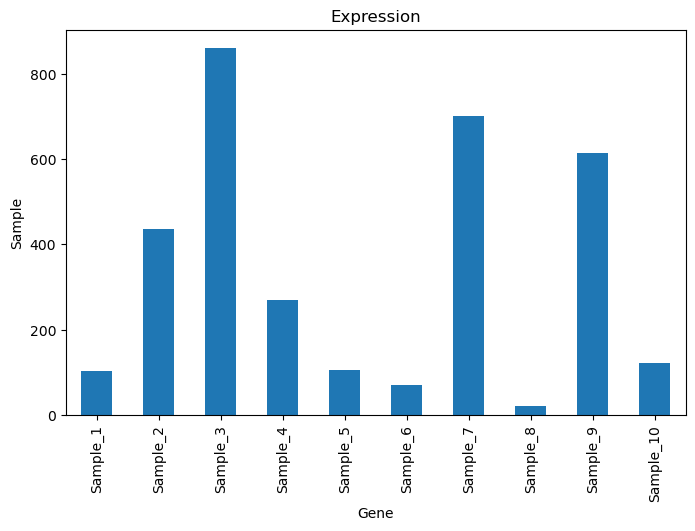

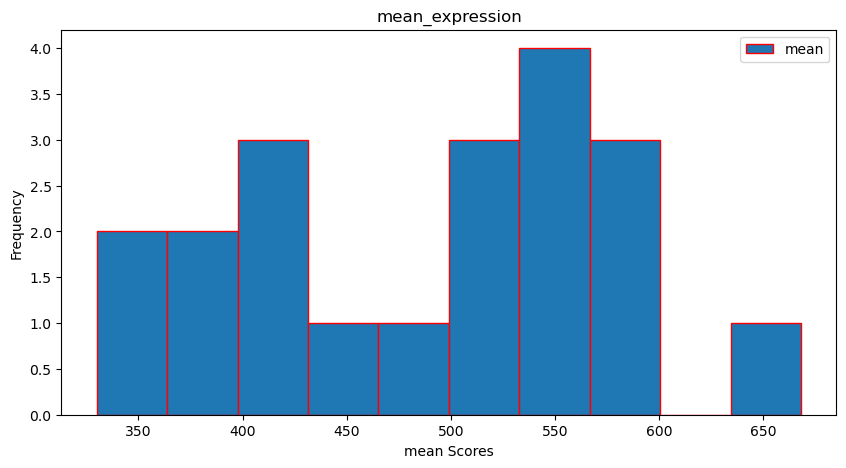

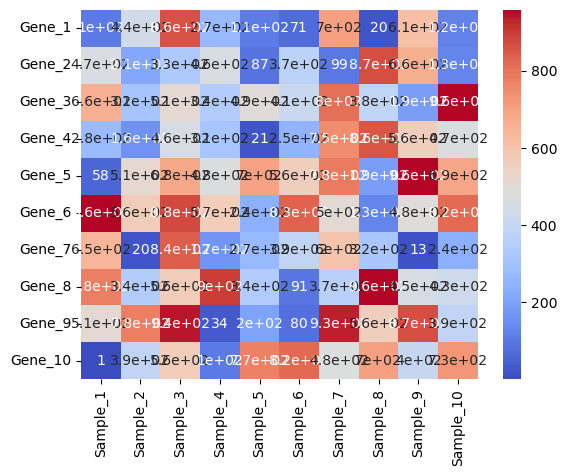

In [85]:
# 6. 数据可视化
import matplotlib.pyplot as plt

# 画第一个基因（Gene_1）在 10 个样本中的表达量柱状图
gen1 = df_expr.loc['Gene_1']
gen1.plot(kind = 'bar',x = 'gen1',xlabel = 'Gene',y = df_expr.columns,ylabel = 'Sample',title = 'Expression',figsize = (8,5))
plt.show()

# 画所有基因的平均表达量分布直方图
mean_data = df_expr.apply(lambda x : x.dropna().mean(),axis = 1).tolist()
data = {'mean':mean_data}
df = pd.DataFrame(data)

df.plot(kind = 'hist',y = 'mean',bins = 10,title = 'mean_expression',xlabel = 'mean Scores',figsize = (10,5),edgecolor = 'red')
plt.show()

#  画对照组 vs 处理组的基因表达箱线图（选 3 个基因画）


# 画基因表达相关性热图（前 10 个基因之间的相关性）
import seaborn as sns

sns.heatmap(df_expr.loc['Gene_1':'Gene_10',:],annot = True,cmap = 'coolwarm')
plt.show()

In [88]:
# 7.数据导出


# 将清洗后的表达矩阵导出为 CSV 文件
df_expr = df_expr.apply(lambda x : x.fillna(x.dropna().mean()),axis = 1)
df_expr.to_csv("/mnt/c/Users/18371/Desktop/Pandas 实践集/gene_test.csv")

# 将分组统计结果（对照组和处理组的均值）导出为 Excel 文件

# 将合并后的完整数据（表达 + 注释）导出为 CSV
result.to_csv("/mnt/c/Users/18371/Desktop/Pandas 实践集/gene_test_multiple.csv")